In [ ]:
# ATIVIDADE DIRIGIDA 2 — Regressão + Gradiente Descendente
# Dataset: heat_exchanger.csv

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from mpl_toolkits.mplot3d import Axes3D
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 120

In [4]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/heat_exchanger.csv')

# df = pd.read_csv('heat_exchanger.csv')

print("Shape:", df.shape)
print("\nPrimeiras linhas:")
display(df.head())
print("\nInfo:")
df.info()
print("\nEstatísticas descritivas:")
display(df.describe())

df_model = df.copy()

# Criar coluna indice_tempo a partir do timestamp
df_model['timestamp'] = pd.to_datetime(df_model['timestamp'])
df_model['indice_tempo'] = (df_model['timestamp'] - df_model['timestamp'].min()).dt.days

# Remover coluna original de data
df_model = df_model.drop(columns=['timestamp'])

print("\nColunas após pré-processamento:")
print(df_model.columns.tolist())
print("\nVerificação de nulos:")
print(df_model.isnull().sum())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape: (175, 6)

Primeiras linhas:


,timestamp,water_inlet_temperature,glycol_inlet_temperature,out_glycol_temperature,out_water_temperature,heat_efficiency
0,2022-01-01,33.49,85.82,46.50,61.808856,96.454517
1,2022-01-02,33.51,86.35,46.75,61.894941,96.432576
2,2022-01-03,33.39,85.98,46.55,61.672872,96.410674
3,2022-01-04,33.32,85.71,46.51,61.403079,96.388810
4,2022-01-05,32.86,87.54,46.71,61.583481,96.366986



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175 entries, 0 to 174
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   timestamp                 175 non-null    object 
 1   water_inlet_temperature   175 non-null    float64
 2   glycol_inlet_temperature  175 non-null    float64
 3   out_glycol_temperature    175 non-null    float64
 4   out_water_temperature     175 non-null    float64
 5   heat_efficiency           175 non-null    float64
dtypes: float64(5), object(1)
memory usage: 8.3+ KB

Estatísticas descritivas:


,water_inlet_temperature,glycol_inlet_temperature,out_glycol_temperature,out_water_temperature,heat_efficiency
count,175.000000,175.000000,175.000000,175.000000,175.000000
mean,31.441943,69.699429,41.350343,51.461277,94.741801
std,2.382263,24.781046,7.686540,13.872204,0.941302
min,20.850000,21.110000,20.700000,21.262971,93.225263
25%,30.910000,31.545000,31.565000,33.128821,93.921594
50%,32.100000,84.130000,45.580000,59.250579,94.691906
75%,32.770000,85.845000,46.485000,60.107158,95.536221
max,35.930000,89.180000,48.970000,64.060976,96.454517



Colunas após pré-processamento:
['water_inlet_temperature', 'glycol_inlet_temperature', 'out_glycol_temperature', 'out_water_temperature', 'heat_efficiency', 'indice_tempo']

Verificação de nulos:
water_inlet_temperature     0
glycol_inlet_temperature    0
out_glycol_temperature      0
out_water_temperature       0
heat_efficiency             0
indice_tempo                0
dtype: int64


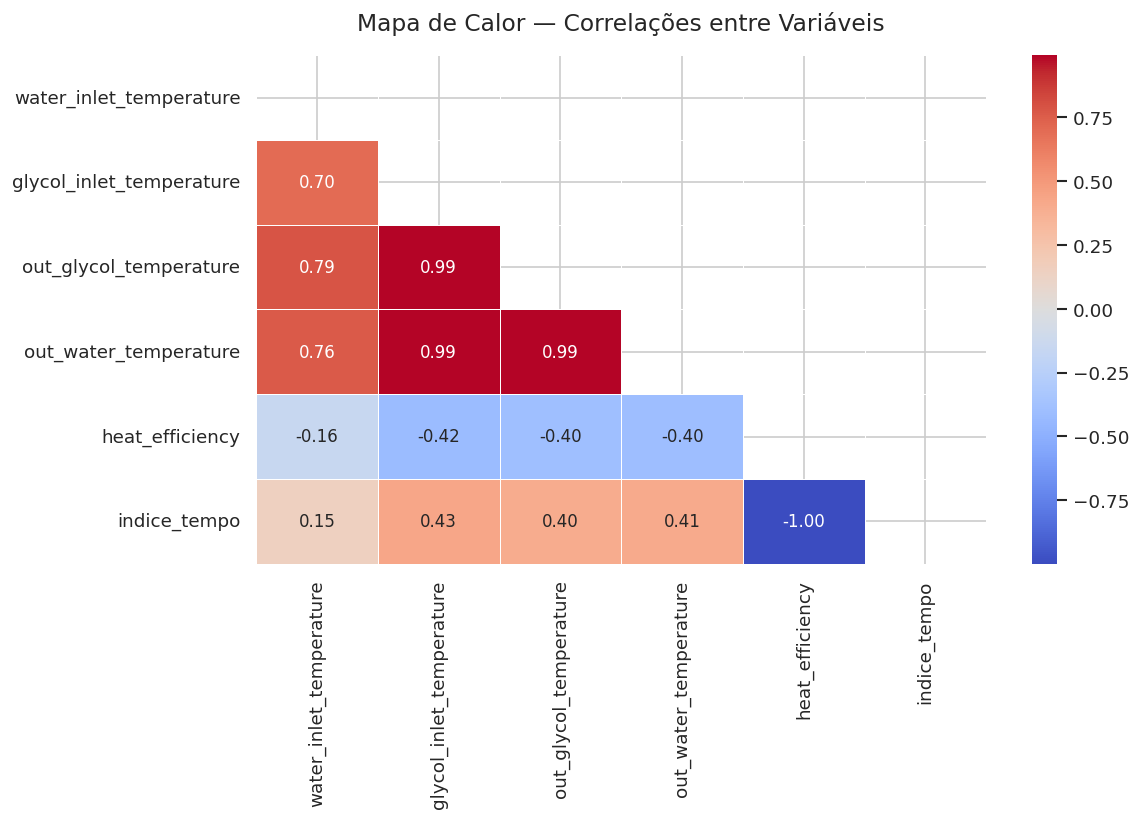


Correlação com heat_efficiency:
water_inlet_temperature    -0.157427
out_glycol_temperature     -0.396436
out_water_temperature      -0.402299
glycol_inlet_temperature   -0.421220
indice_tempo               -0.998751
Name: heat_efficiency, dtype: float64


In [5]:
corr_matrix = df_model.corr()

plt.figure(figsize=(10, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    annot_kws={"size": 10}
)
plt.title('Mapa de Calor — Correlações entre Variáveis', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

# Correlações com a variável alvo
TARGET = 'heat_efficiency'
print(f"\nCorrelação com {TARGET}:")
corr_target = corr_matrix[TARGET].drop(TARGET).sort_values(ascending=False)
print(corr_target)

Top 2 variáveis: ['indice_tempo', 'glycol_inlet_temperature']

Modelo 1 (1 variável)
  R²:   0.9984 | RMSE: 0.0379
  Coeficientes: {'indice_tempo': np.float64(-0.0179)}
  Intercepto:   96.3394

Modelo 2 (2 variáveis)
  R²:   0.9985 | RMSE: 0.0369
  Coeficientes: {'indice_tempo': np.float64(-0.0179), 'glycol_inlet_temperature': np.float64(0.0001)}
  Intercepto:   96.3323

Modelo 3 (completo)
  R²:   0.9986 | RMSE: 0.0349
  Coeficientes: {'water_inlet_temperature': np.float64(0.0123), 'glycol_inlet_temperature': np.float64(0.013), 'out_glycol_temperature': np.float64(-0.0202), 'out_water_temperature': np.float64(-0.0134), 'indice_tempo': np.float64(-0.018)}
  Intercepto:   96.5763


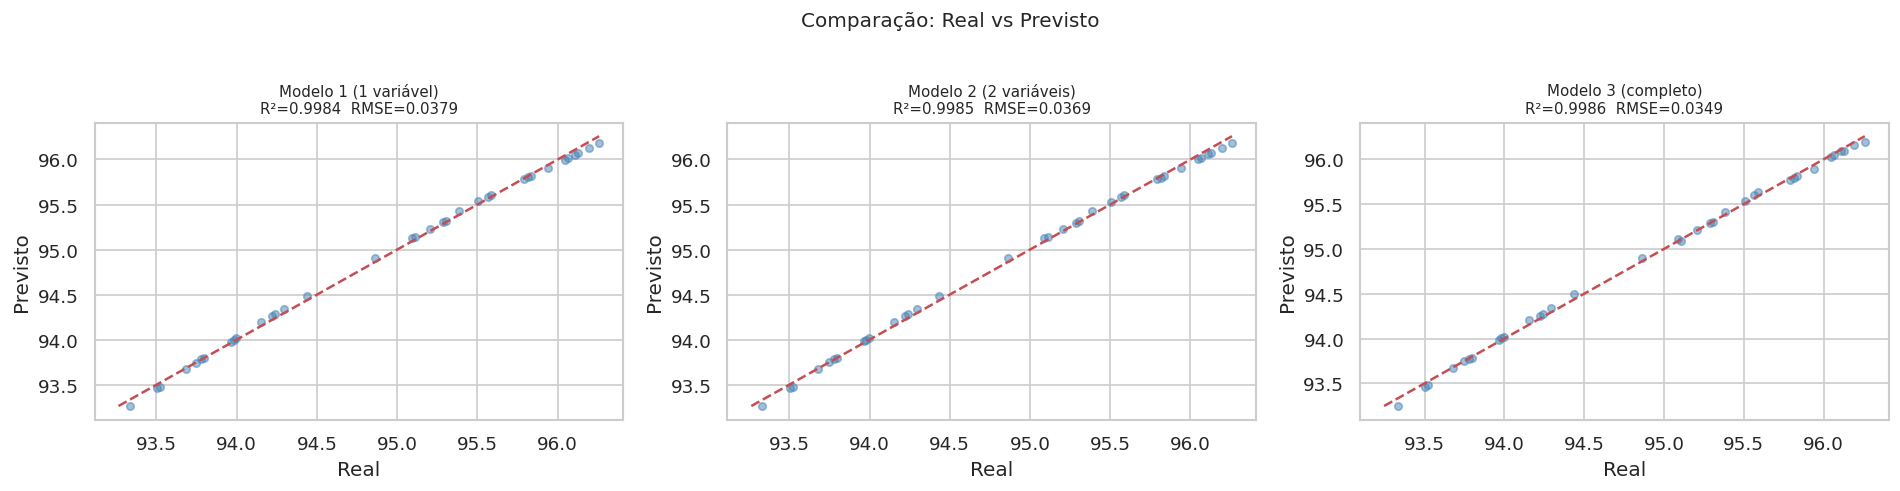


--- Resumo Comparativo (sklearn) ---


,R²,RMSE
Modelo 1 (1 variável),0.9984,0.0379
Modelo 2 (2 variáveis),0.9985,0.0369
Modelo 3 (completo),0.9986,0.0349


In [6]:
feature_cols = [c for c in df_model.columns if c != TARGET]

# Top 2 variáveis mais correlacionadas
top2 = corr_target.abs().nlargest(2).index.tolist()
print(f"Top 2 variáveis: {top2}")

modelos = {
    'Modelo 1 (1 variável)' : [top2[0]],
    'Modelo 2 (2 variáveis)': top2,
    'Modelo 3 (completo)'   : feature_cols
}

resultados = {}

for nome, features in modelos.items():
    X = df_model[features]
    y = df_model[TARGET]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    reg = LinearRegression()
    reg.fit(X_train, y_train)
    y_pred = reg.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)

    resultados[nome] = {
        'Features': features, 'R²': round(r2, 4), 'RMSE': round(rmse, 4),
        'Modelo': reg, 'X_test': X_test, 'y_test': y_test, 'y_pred': y_pred
    }
    print(f"\n{nome}")
    print(f"  R²:   {r2:.4f} | RMSE: {rmse:.4f}")
    print(f"  Coeficientes: {dict(zip(features, reg.coef_.round(4)))}")
    print(f"  Intercepto:   {reg.intercept_:.4f}")

# Comparação visual
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (nome, res) in zip(axes, resultados.items()):
    ax.scatter(res['y_test'], res['y_pred'], alpha=0.5, s=20, color='steelblue')
    lims = [min(res['y_test'].min(), res['y_pred'].min()),
            max(res['y_test'].max(), res['y_pred'].max())]
    ax.plot(lims, lims, 'r--', linewidth=1.5)
    ax.set_title(f"{nome}\nR²={res['R²']}  RMSE={res['RMSE']}", fontsize=9)
    ax.set_xlabel("Real"); ax.set_ylabel("Previsto")
plt.suptitle("Comparação: Real vs Previsto", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# Tabela resumo
resumo = pd.DataFrame({k: {'R²': v['R²'], 'RMSE': v['RMSE']} for k, v in resultados.items()}).T
print("\n--- Resumo Comparativo (sklearn) ---")
display(resumo)

Treinamento concluído!
Loss final (MSE/2): 0.001265

--- Gradiente Descendente (manual) ---
  R²:   0.9984
  RMSE: 0.0373


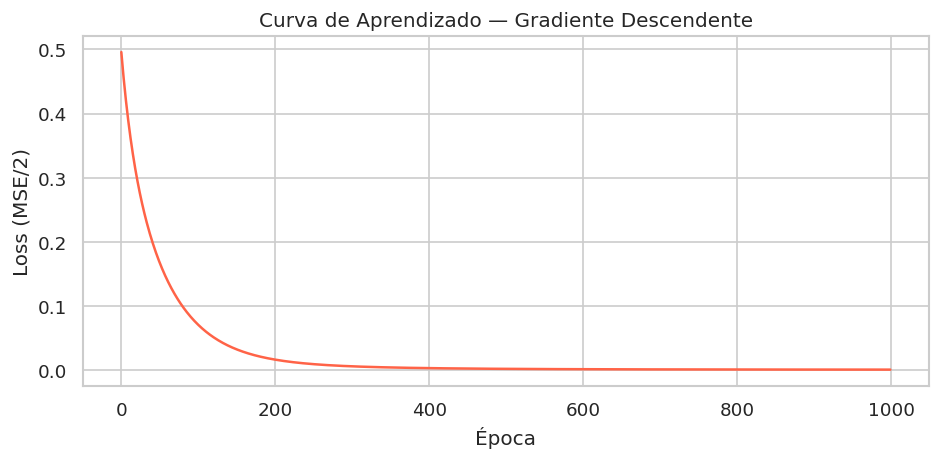

In [7]:
# Preparar dados (normalizar é essencial para GD convergir bem)
X_all = df_model[feature_cols].values
y_all = df_model[TARGET].values

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X_all)
y_scaled = scaler_y.fit_transform(y_all.reshape(-1, 1)).ravel()

X_tr, X_te, y_tr, y_te = train_test_split(
    X_scaled, y_scaled, test_size=0.2, random_state=42
)

# Adiciona coluna de bias (intercepto)
X_tr_b = np.c_[np.ones(X_tr.shape[0]), X_tr]
X_te_b = np.c_[np.ones(X_te.shape[0]), X_te]

# ---- Hiperparâmetros ----
learning_rate = 0.01
n_epochs      = 1000
m             = X_tr_b.shape[0]   # nº de amostras

# ---- Inicialização dos pesos ----
np.random.seed(42)
theta = np.zeros(X_tr_b.shape[1])

historico_loss = []

# ---- Loop de treinamento ----
for epoch in range(n_epochs):
    y_pred_tr = X_tr_b @ theta
    erro      = y_pred_tr - y_tr
    gradiente = (1 / m) * X_tr_b.T @ erro
    theta    -= learning_rate * gradiente
    loss      = (1 / (2 * m)) * np.sum(erro ** 2)
    historico_loss.append(loss)

print("Treinamento concluído!")
print(f"Loss final (MSE/2): {historico_loss[-1]:.6f}")

# ---- Avaliação no conjunto de teste ----
y_pred_gd_scaled = X_te_b @ theta

# Desnormalizar predições e valores reais
y_pred_gd = scaler_y.inverse_transform(y_pred_gd_scaled.reshape(-1, 1)).ravel()
y_te_orig = scaler_y.inverse_transform(y_te.reshape(-1, 1)).ravel()

rmse_gd = np.sqrt(mean_squared_error(y_te_orig, y_pred_gd))
r2_gd   = r2_score(y_te_orig, y_pred_gd)

print(f"\n--- Gradiente Descendente (manual) ---")
print(f"  R²:   {r2_gd:.4f}")
print(f"  RMSE: {rmse_gd:.4f}")

# ---- Curva de aprendizado ----
plt.figure(figsize=(8, 4))
plt.plot(historico_loss, color='tomato', linewidth=1.5)
plt.xlabel("Época")
plt.ylabel("Loss (MSE/2)")
plt.title("Curva de Aprendizado — Gradiente Descendente")
plt.tight_layout()
plt.show()

--- Comparação sklearn vs Gradiente Descendente ---


,Método,R²,RMSE
0,sklearn (OLS),0.9986,0.0349
1,Gradiente Descendente,0.9984,0.0373


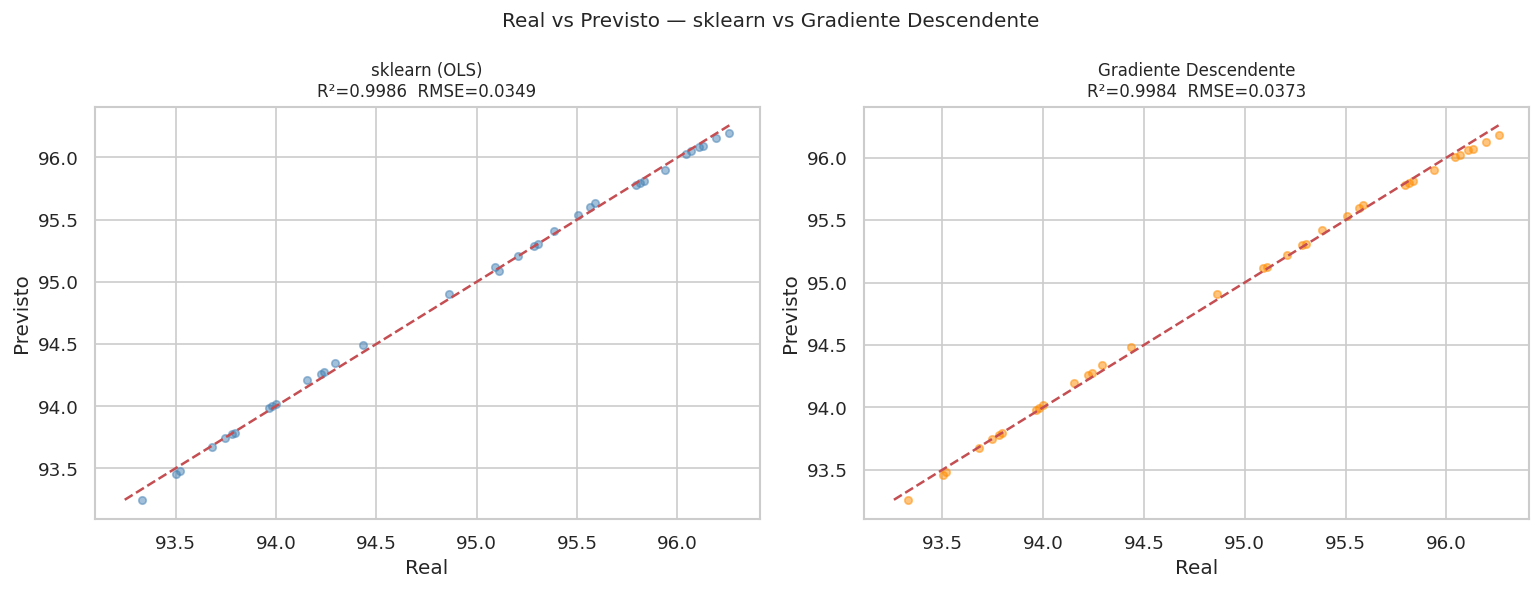

In [8]:
r2_sk   = resultados['Modelo 3 (completo)']['R²']
rmse_sk = resultados['Modelo 3 (completo)']['RMSE']

comp = pd.DataFrame({
    'Método'       : ['sklearn (OLS)', 'Gradiente Descendente'],
    'R²'           : [r2_sk, round(r2_gd, 4)],
    'RMSE'         : [rmse_sk, round(rmse_gd, 4)],
})
print("--- Comparação sklearn vs Gradiente Descendente ---")
display(comp)

# Gráfico lado a lado
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# sklearn
res_sk = resultados['Modelo 3 (completo)']
axes[0].scatter(res_sk['y_test'], res_sk['y_pred'], alpha=0.5, s=20, color='steelblue')
lims = [min(res_sk['y_test'].min(), res_sk['y_pred'].min()),
        max(res_sk['y_test'].max(), res_sk['y_pred'].max())]
axes[0].plot(lims, lims, 'r--', linewidth=1.5)
axes[0].set_title(f"sklearn (OLS)\nR²={r2_sk}  RMSE={rmse_sk}", fontsize=10)
axes[0].set_xlabel("Real"); axes[0].set_ylabel("Previsto")

# Gradiente Descendente
axes[1].scatter(y_te_orig, y_pred_gd, alpha=0.5, s=20, color='darkorange')
lims2 = [min(y_te_orig.min(), y_pred_gd.min()),
         max(y_te_orig.max(), y_pred_gd.max())]
axes[1].plot(lims2, lims2, 'r--', linewidth=1.5)
axes[1].set_title(f"Gradiente Descendente\nR²={round(r2_gd,4)}  RMSE={round(rmse_gd,4)}", fontsize=10)
axes[1].set_xlabel("Real"); axes[1].set_ylabel("Previsto")

plt.suptitle("Real vs Previsto — sklearn vs Gradiente Descendente", fontsize=12)
plt.tight_layout()
plt.show()

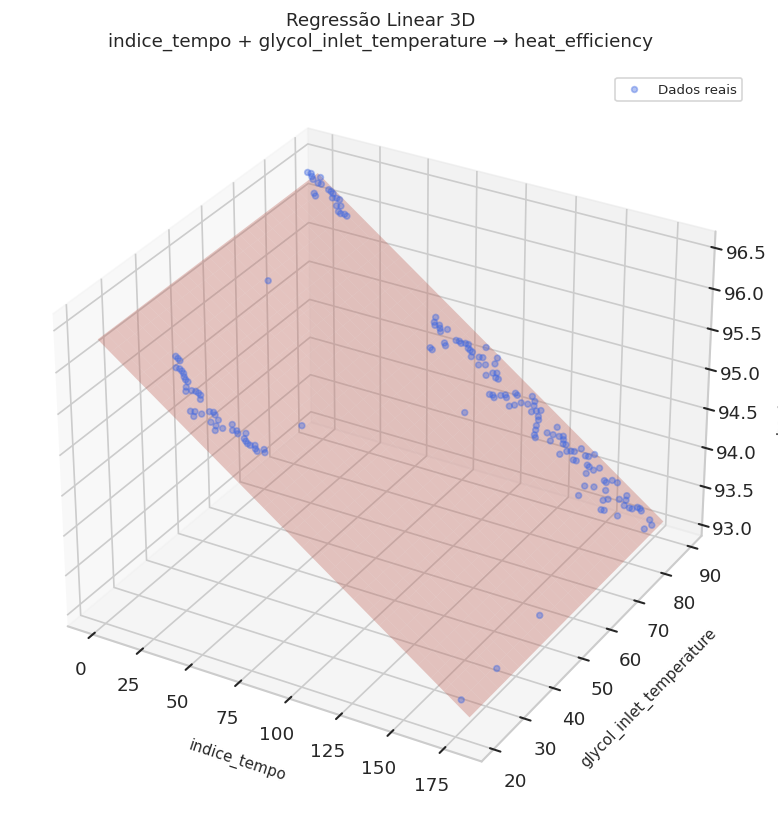


Equação do modelo 3D:
  heat_efficiency = 96.3306 + -0.0180·indice_tempo + 0.0002·glycol_inlet_temperature


In [9]:
var1, var2 = top2[0], top2[1]

X2 = df_model[[var1, var2]]
y  = df_model[TARGET]

reg2 = LinearRegression()
reg2.fit(X2, y)

v1_range = np.linspace(X2[var1].min(), X2[var1].max(), 30)
v2_range = np.linspace(X2[var2].min(), X2[var2].max(), 30)
V1, V2 = np.meshgrid(v1_range, v2_range)

Z = reg2.intercept_ + reg2.coef_[0] * V1 + reg2.coef_[1] * V2

fig = plt.figure(figsize=(11, 7))
ax  = fig.add_subplot(111, projection='3d')

ax.scatter(df_model[var1], df_model[var2], y,
           color='royalblue', alpha=0.4, s=12, label='Dados reais')
ax.plot_surface(V1, V2, Z, alpha=0.35, color='salmon', edgecolor='none')

ax.set_xlabel(var1, fontsize=9, labelpad=8)
ax.set_ylabel(var2, fontsize=9, labelpad=8)
ax.set_zlabel(TARGET, fontsize=9, labelpad=8)
ax.set_title(f'Regressão Linear 3D\n{var1} + {var2} → {TARGET}', fontsize=11, pad=15)
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"\nEquação do modelo 3D:")
print(f"  {TARGET} = {reg2.intercept_:.4f}"
      f" + {reg2.coef_[0]:.4f}·{var1}"
      f" + {reg2.coef_[1]:.4f}·{var2}")